In [1]:
import pypsa
import xarray as xr
import linopy as lp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import beta
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error

In [2]:
# SOC indem die Füllstände des H2 Stores aufsummiert werden und durch die installierte Kapazität geteilt werden

def get_hydrogen_soc(n):
    hydrogen_e = 0
    hydrogen_e_nom = 0

    for year in [2035, 2030, 2020]:

        hydrogen_e += n.stores_t.e[f"DE0 0 H2 Store-{year}"]
        hydrogen_e_nom += n.stores.e_nom[f"DE0 0 H2 Store-{year}"]

    soc = hydrogen_e / hydrogen_e_nom

    return soc

In [3]:
from typing import Dict, Any

co2_prices = {
    "2020": 28,
    "2025": 70,
    "2030": 130,
    "2035": 190,
    "2040": 210,
    "2045": 530,
}

specific_emissions = {
    "oil" : 0.2571,
    "oil primary" : 0.2571,
    "gas" : 0.198, # OCGT
    "gas primary" : 0.198, # OCGT
    "coal" : 0.3361,
    "lignite" : 0.4069,
}

def add_carbon_price(n, co2_price, specific_emissions):
        
    for carrier in specific_emissions.keys():
        n.generators.loc[n.generators.carrier == carrier, "marginal_cost"] += (
            co2_price * specific_emissions[carrier]
        )


In [4]:
n = pypsa.Network('base_s_1__none_2035_lt.nc')
n.optimize.fix_optimal_capacities()
n.optimize.create_model()

n_perfect_foresight = pypsa.Network('base_s_1__none_2035_lt.nc')
n_perfect_foresight.optimize.fix_optimal_capacities()
n_perfect_foresight.optimize.create_model()

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2000', 'DE0 0 urban central oil CHP-2000',
       'DE0 0 urban central gas CHP-2005', 'DE0 0 urban central oil CHP-2005',
       'DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central coal CHP-2015', 'DE0 0 urban central gas CHP-2015',
       'DE0 0 urban central lignite CHP-2015',
       'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central solid biomass CHP-2015',
       'DE0 0 urban central coal CHP-2020', 'DE0 0 urban central gas CHP-2020',
       'DE0 0 urban central lignite CHP-2020',
       'DE0 0 urban central oil CHP-2020',
       'DE0 0 urban central solid biomass CHP-2020', 'DE0 0 CCGT-1965',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-1995', 'DE0 0 CCGT-2000',
       'DE0 0 CCGT-2005', 'DE

Linopy LP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)
 * Store-e (snapshot, Store)
 * StorageUnit-p_dispatch (snapshot, StorageUnit)
 * StorageUnit-p_store (snapshot, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, StorageUnit)
 * StorageUnit-spill (snapshot, StorageUnit)
 * Store-p (snapshot, Store)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Store-fix-e-lower (snapshot, Store-fix)
 * Store-fix-e-upper (snapshot, Store-fix)
 * StorageUnit-fix-p_dispatch-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_dispatch-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_o

In [5]:
n_perfect_foresight.optimize.solve_model(
    solver_name = 'gurobi'
)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 12.33it/s]
INFO:linopy.io: Writing time: 5.86s


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 109596 iterations and 25.75 seconds (15.70 work units)


INFO:gurobipy:Solved in 109596 iterations and 25.75 seconds (15.70 work units)


Optimal objective  4.013045735e+10


INFO:gurobipy:Optimal objective  4.013045735e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 732907 primals, 1509647 duals
Objective: 4.01e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

In [6]:
n.optimize.optimize_with_rolling_horizon(
    horizon = 48,
    overlap = 8,
    solver_name='gurobi'
)

INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-01 00:00:00:2019-01-06 21:00:00] (1/73).
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2000', 'DE0 0 urban central oil CHP-2000',
       'DE0 0 urban central gas CHP-2005', 'DE0 0 urban central oil CHP-2005',
       'DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central coal CHP-2015', 'DE0 0 urban central gas CHP-2015',
       'DE0 0 urban central lignite CHP-2015',
       'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central solid biomass CHP-2015',
       'DE0 0 urban central coal CHP-2020', 'DE0 0 urban central gas CHP-2020',
       'DE0 0 urban central lignite CHP-2020',
       'DE0 0 urban central oil CHP-2020',
       'DE0 0 urban central solid biomass CHP-2020', 'DE0 0 CCGT-1965',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-1995', 'DE0 0 CCGT-2000',
       'DE0 0 CCGT-2005', 'DE0 0 CCGT-2010', 'DE0 0 

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 0 iterations and 0.00 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.00 seconds (0.00 work units)


Infeasible or unbounded model


INFO:gurobipy:Infeasible or unbounded model
INFO:linopy.solvers:Unable to save solution file. Raised error: Unable to retrieve attribute 'X'
Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4



Unnamed PyPSA Network
---------------------
Components:
 - Bus: 47
 - Carrier: 96
 - Generator: 40
 - GlobalConstraint: 15
 - Link: 144
 - Load: 23
 - StorageUnit: 2
 - Store: 30
Snapshots: 2920

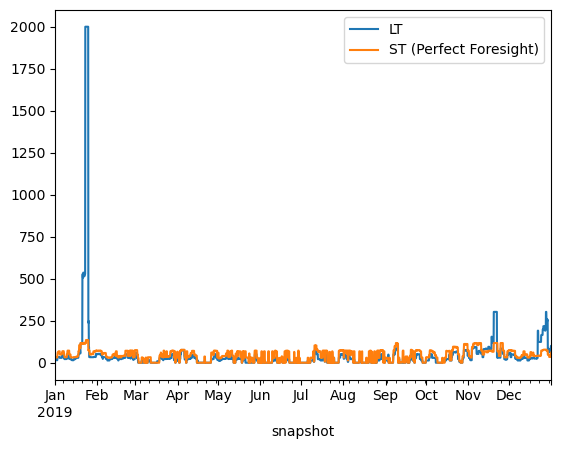

In [7]:
n.buses_t.marginal_price['DE0 0'].plot(label='LT')
n_perfect_foresight.buses_t.marginal_price['DE0 0'].plot(label='ST (Perfect Foresight)')
plt.legend()

In [8]:
n_lt = pypsa.Network('base_s_1__none_2035_lt.nc')
n_st_co2price = n_lt.copy()

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [9]:
add_carbon_price(n_st_co2price, co2_prices["2035"], specific_emissions)
n_st_co2price.optimize.fix_optimal_capacities()
n_st_co2price.optimize.create_model()
n_st_co2price.optimize.solve_model(
    solver_name = 'gurobi'
)

Index(['DE0 0 urban central gas CHP-2000', 'DE0 0 urban central oil CHP-2000',
       'DE0 0 urban central gas CHP-2005', 'DE0 0 urban central oil CHP-2005',
       'DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central coal CHP-2015', 'DE0 0 urban central gas CHP-2015',
       'DE0 0 urban central lignite CHP-2015',
       'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central solid biomass CHP-2015',
       'DE0 0 urban central coal CHP-2020', 'DE0 0 urban central gas CHP-2020',
       'DE0 0 urban central lignite CHP-2020',
       'DE0 0 urban central oil CHP-2020',
       'DE0 0 urban central solid biomass CHP-2020', 'DE0 0 CCGT-1965',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-1995', 'DE0 0 CCGT-2000',
       'DE0 0 CCGT-2005', 'DE0 0 CCGT-2010', 'DE0 0 CCGT-2015',
       'DE0 0 CCGT-2020', 'DE0 0 rural oil boiler-2019',
       'DE0 0 urban decentral oil boiler-2019', 'DE0 0 H2 OCGT-2035',
       'DE0 0 H2 retrofit OCGT-2030'],
    

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 100615 iterations and 19.95 seconds (12.35 work units)


INFO:gurobipy:Solved in 100615 iterations and 19.95 seconds (12.35 work units)


Optimal objective  8.649953572e+10


INFO:gurobipy:Optimal objective  8.649953572e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 732907 primals, 1509647 duals
Objective: 8.65e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

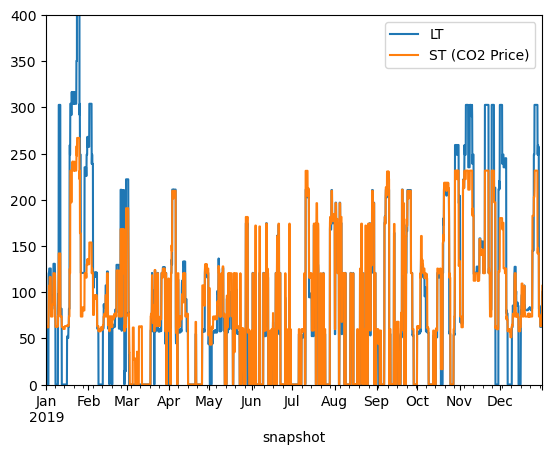

In [19]:
n_lt.buses_t.marginal_price['DE0 0'].plot(label='LT')
# n_perfect_foresight.buses_t.marginal_price['DE0 0'].plot(label='ST (Perfect Foresight)')
n_st_co2price.buses_t.marginal_price['DE0 0'].plot(label='ST (CO2 Price)')
plt.ylim(0, 400)
plt.legend()


In [22]:
round(n_lt.statistics.supply(bus_carrier="AC") / 1e6)

component    carrier                        
Link         CCGT                                26.0
             H2 Fuel Cell                         0.0
             H2 OCGT                              9.0
             H2 retrofit OCGT                     1.0
             Open-Cycle Gas                       0.0
             battery discharger                  53.0
             coal                                 3.0
             lignite                              8.0
             oil                                  0.0
             solid biomass                        0.0
             urban central coal CHP               4.0
             urban central gas CHP               41.0
             urban central lignite CHP            0.0
             urban central oil CHP                0.0
             urban central solid biomass CHP      1.0
StorageUnit  Pumped Hydro Storage                 4.0
             Reservoir & Dam                      2.0
Generator    Offshore Wind (AC)      

In [23]:
round(n_st_co2price.statistics.supply(bus_carrier="AC") / 1e6)

component    carrier                        
Link         CCGT                                25.0
             H2 Fuel Cell                         0.0
             H2 OCGT                              6.0
             H2 retrofit OCGT                     0.0
             Open-Cycle Gas                       0.0
             battery discharger                  54.0
             coal                                 2.0
             lignite                              1.0
             solid biomass                        0.0
             urban central coal CHP               4.0
             urban central gas CHP               37.0
             urban central lignite CHP            0.0
             urban central solid biomass CHP      5.0
StorageUnit  Pumped Hydro Storage                 4.0
             Reservoir & Dam                      2.0
Generator    Offshore Wind (AC)                  31.0
             Offshore Wind (DC)                 200.0
             Onshore Wind            

In [11]:
n_st_co2price_rh = n_lt.copy()
add_carbon_price(n_st_co2price_rh, co2_prices["2035"], specific_emissions)
n_st_co2price_rh.optimize.fix_optimal_capacities()
n_st_co2price_rh.optimize.create_model()
n_st_co2price_rh.optimize.optimize_with_rolling_horizon(
    horizon = 48,
    overlap = 8,
    solver_name='gurobi'
)

Index(['DE0 0 urban central gas CHP-2000', 'DE0 0 urban central oil CHP-2000',
       'DE0 0 urban central gas CHP-2005', 'DE0 0 urban central oil CHP-2005',
       'DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central coal CHP-2015', 'DE0 0 urban central gas CHP-2015',
       'DE0 0 urban central lignite CHP-2015',
       'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central solid biomass CHP-2015',
       'DE0 0 urban central coal CHP-2020', 'DE0 0 urban central gas CHP-2020',
       'DE0 0 urban central lignite CHP-2020',
       'DE0 0 urban central oil CHP-2020',
       'DE0 0 urban central solid biomass CHP-2020', 'DE0 0 CCGT-1965',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-1995', 'DE0 0 CCGT-2000',
       'DE0 0 CCGT-2005', 'DE0 0 CCGT-2010', 'DE0 0 CCGT-2015',
       'DE0 0 CCGT-2020', 'DE0 0 rural oil boiler-2019',
       'DE0 0 urban decentral oil boiler-2019', 'DE0 0 H2 OCGT-2035',
       'DE0 0 H2 retrofit OCGT-2030'],
    

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 1410 iterations and 0.04 seconds (0.04 work units)


INFO:gurobipy:Solved in 1410 iterations and 0.04 seconds (0.04 work units)


Optimal objective  1.592579120e+09


INFO:gurobipy:Optimal objective  1.592579120e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 10040 primals, 20687 duals
Objective: 1.59e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 47
 - Carrier: 96
 - Generator: 40
 - GlobalConstraint: 15
 - Link: 144
 - Load: 23
 - StorageUnit: 2
 - Store: 30
Snapshots: 2920

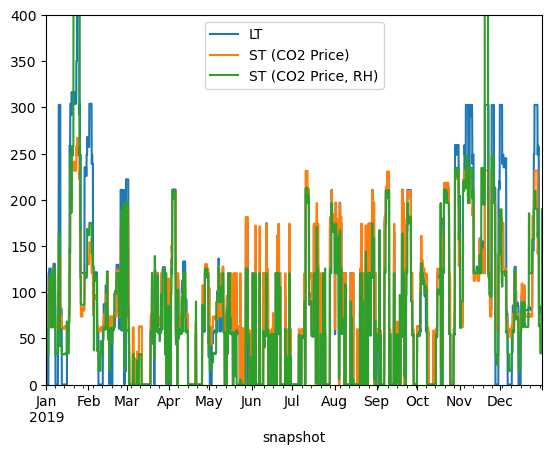

In [20]:
n_lt.buses_t.marginal_price['DE0 0'].plot(label='LT')
# n_perfect_foresight.buses_t.marginal_price['DE0 0'].plot(label='ST (Perfect Foresight)')
n_st_co2price.buses_t.marginal_price['DE0 0'].plot(label='ST (CO2 Price)')
n_st_co2price_rh.buses_t.marginal_price['DE0 0'].plot(label='ST (CO2 Price, RH)')
plt.ylim(0, 400)
plt.legend()

In [21]:
lmps = pd.concat([
    n_lt.buses_t.marginal_price['DE0 0'],
    n_st_co2price.buses_t.marginal_price['DE0 0'],
    n_st_co2price_rh.buses_t.marginal_price['DE0 0']
], axis=1)

lmps.columns = ['LT', 'ST (CO2 Price)', 'ST (CO2 Price, RH)']
lmps.describe()

,LT,ST (CO2 Price),"ST (CO2 Price, RH)"
count,2920.000000,2920.000000,2920.000000
mean,96.629048,88.739365,98.674652
std,127.512748,71.824679,215.081704
min,0.035115,0.035117,0.035117
25%,0.058193,28.120451,0.129873
50%,62.483105,73.577731,57.301816
75%,127.399611,125.479381,120.439399
max,1401.208942,266.837863,2000.010004


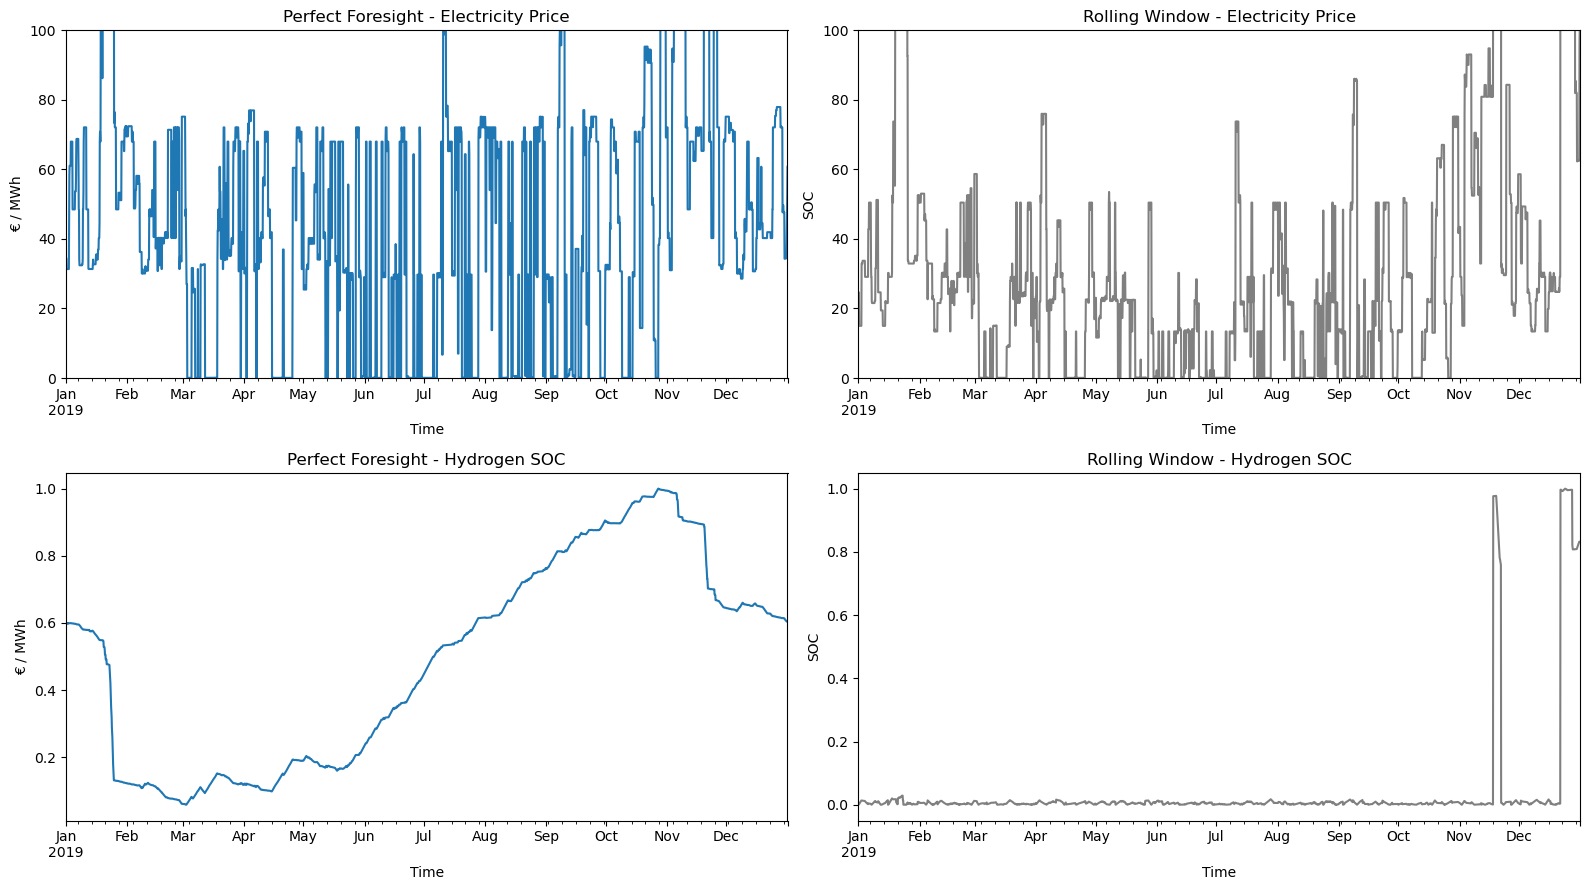

In [12]:
fig, ax = plt.subplots(2,2, figsize=(16,9))

n_perfect_foresight.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][0],
    ylim=(0, 100),
    title = 'Perfect Foresight - Electricity Price'
)

n.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][1],
    ylim = (0, 100),
    title = 'Rolling Window - Electricity Price',
    color = 'grey'
)

get_hydrogen_soc(n_perfect_foresight).plot(
    ax = ax[1][0],
    title = 'Perfect Foresight - Hydrogen SOC'
)
get_hydrogen_soc(n).plot(
    ax = ax[1][1],
    title = 'Rolling Window - Hydrogen SOC',
    color = 'grey'

)

ax[0][0].set_xlabel("Time")
ax[1][0].set_xlabel("Time")
ax[0][1].set_xlabel("Time")
ax[1][1].set_xlabel("Time")

ax[0][0].set_ylabel("€ / MWh")
ax[1][0].set_ylabel("€ / MWh")
ax[0][1].set_ylabel("SOC")
ax[1][1].set_ylabel("SOC")

plt.tight_layout()


- sieht nicht komplett anders aus
- hydrogen einen geringeren einfluss als im anderen Modell, deswegen sind die Ergebnisse doch ganz ähnlich.
- allerdings cyclic off und konstanter Wert wird auch gut tun

In [13]:
n_perfect_foresight.stores_t.e['DE0 0 H2 Store-2035'][0]

/tmp/ipykernel_55061/2927950973.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



8244550.037918776

In [14]:
n = pypsa.Network('base_s_1__none_2035_lt.nc')

# alle hydrogen related stores
stores = n.stores[n.stores.carrier.str.contains("H2", case=False, na=False)].index

# marginal price für alle der mean
for i in stores:
    n.stores.loc[i, 'marginal_cost'] = n_perfect_foresight.buses_t.marginal_price['DE0 0 H2'].mean()


n.stores.loc['DE0 0 H2 Store-2035', 'e_initial'] = 7177471
n.stores.loc['DE0 0 H2 Store-2035', 'e_cyclic'] = False

n.optimize.fix_optimal_capacities()
n.optimize.create_model()

n.optimize.optimize_with_rolling_horizon(
    horizon = 48,
    overlap = 8,
    solver_name = 'gurobi'
)

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2000', 'DE0 0 urban central oil CHP-2000',
       'DE0 0 urban central gas CHP-2005', 'DE0 0 urban central oil CHP-2005',
       'DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central coal CHP-2015', 'DE0 0 urban central gas CHP-2015',
       'DE0 0 urban central lignite CHP-2015',
       'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central solid biomass CHP-2015',
       'DE0 0 urban central coal CHP-2020', 'DE0 0 urban central gas CHP-2020',
       'DE0 0 urban central lignite CHP-2020',
       'DE0 0 urban central oil CHP-2020',
       'DE0 0 urban central solid biomass CHP-2020', 'DE0 0 CCGT-1965',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-1995', 'DE0 0 CCGT-2000',
       'DE0 0 CCGT-2005', 'DE

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Infeasible or unbounded model


INFO:gurobipy:Infeasible or unbounded model
INFO:linopy.solvers:Unable to save solution file. Raised error: Unable to retrieve attribute 'X'
Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4



Unnamed PyPSA Network
---------------------
Components:
 - Bus: 47
 - Carrier: 96
 - Generator: 40
 - GlobalConstraint: 15
 - Link: 144
 - Load: 23
 - StorageUnit: 2
 - Store: 30
Snapshots: 2920

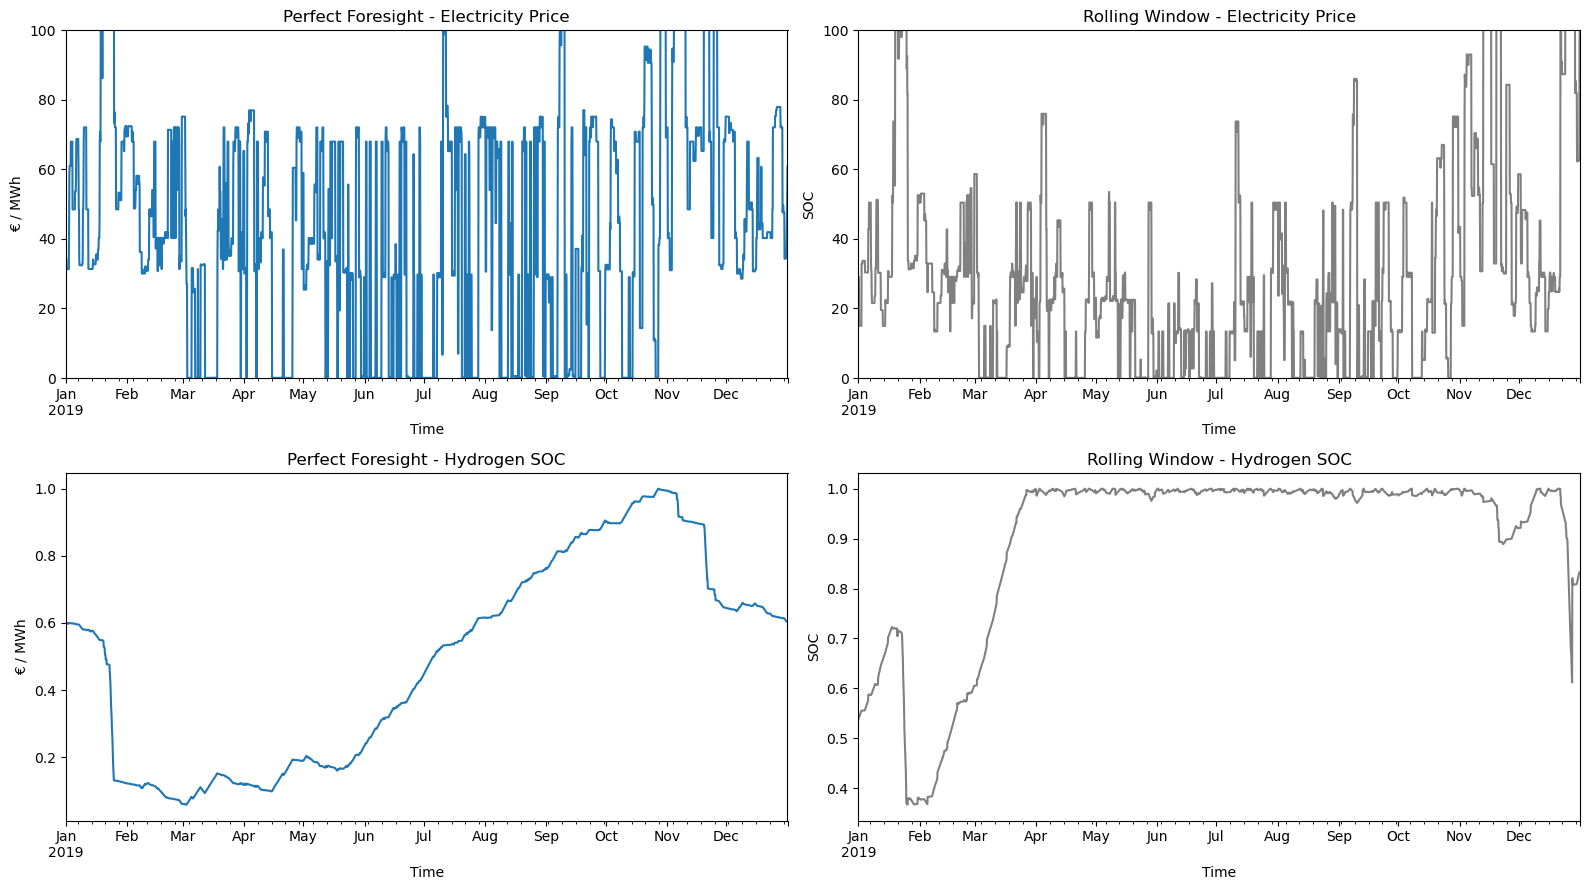

In [15]:
fig, ax = plt.subplots(2,2, figsize=(16,9))

n_perfect_foresight.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][0],
    ylim=(0, 100),
    title = 'Perfect Foresight - Electricity Price'
)

n.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][1],
    ylim = (0, 100),
    title = 'Rolling Window - Electricity Price',
    color = 'grey'
)

get_hydrogen_soc(n_perfect_foresight).plot(
    ax = ax[1][0],
    title = 'Perfect Foresight - Hydrogen SOC'
)
get_hydrogen_soc(n).plot(
    ax = ax[1][1],
    title = 'Rolling Window - Hydrogen SOC',
    color = 'grey'

)

ax[0][0].set_xlabel("Time")
ax[1][0].set_xlabel("Time")
ax[0][1].set_xlabel("Time")
ax[1][1].set_xlabel("Time")

ax[0][0].set_ylabel("€ / MWh")
ax[1][0].set_ylabel("€ / MWh")
ax[0][1].set_ylabel("SOC")
ax[1][1].set_ylabel("SOC")

plt.tight_layout()

- Preisunterschied im März löst es, deswegen den im Sommer vermutlich auch, sobald man einen Verbraucher einfhrt sodass der Speicher nicht bei 100% landet und dadurch den marginal preis verändert

# Erzeugung:

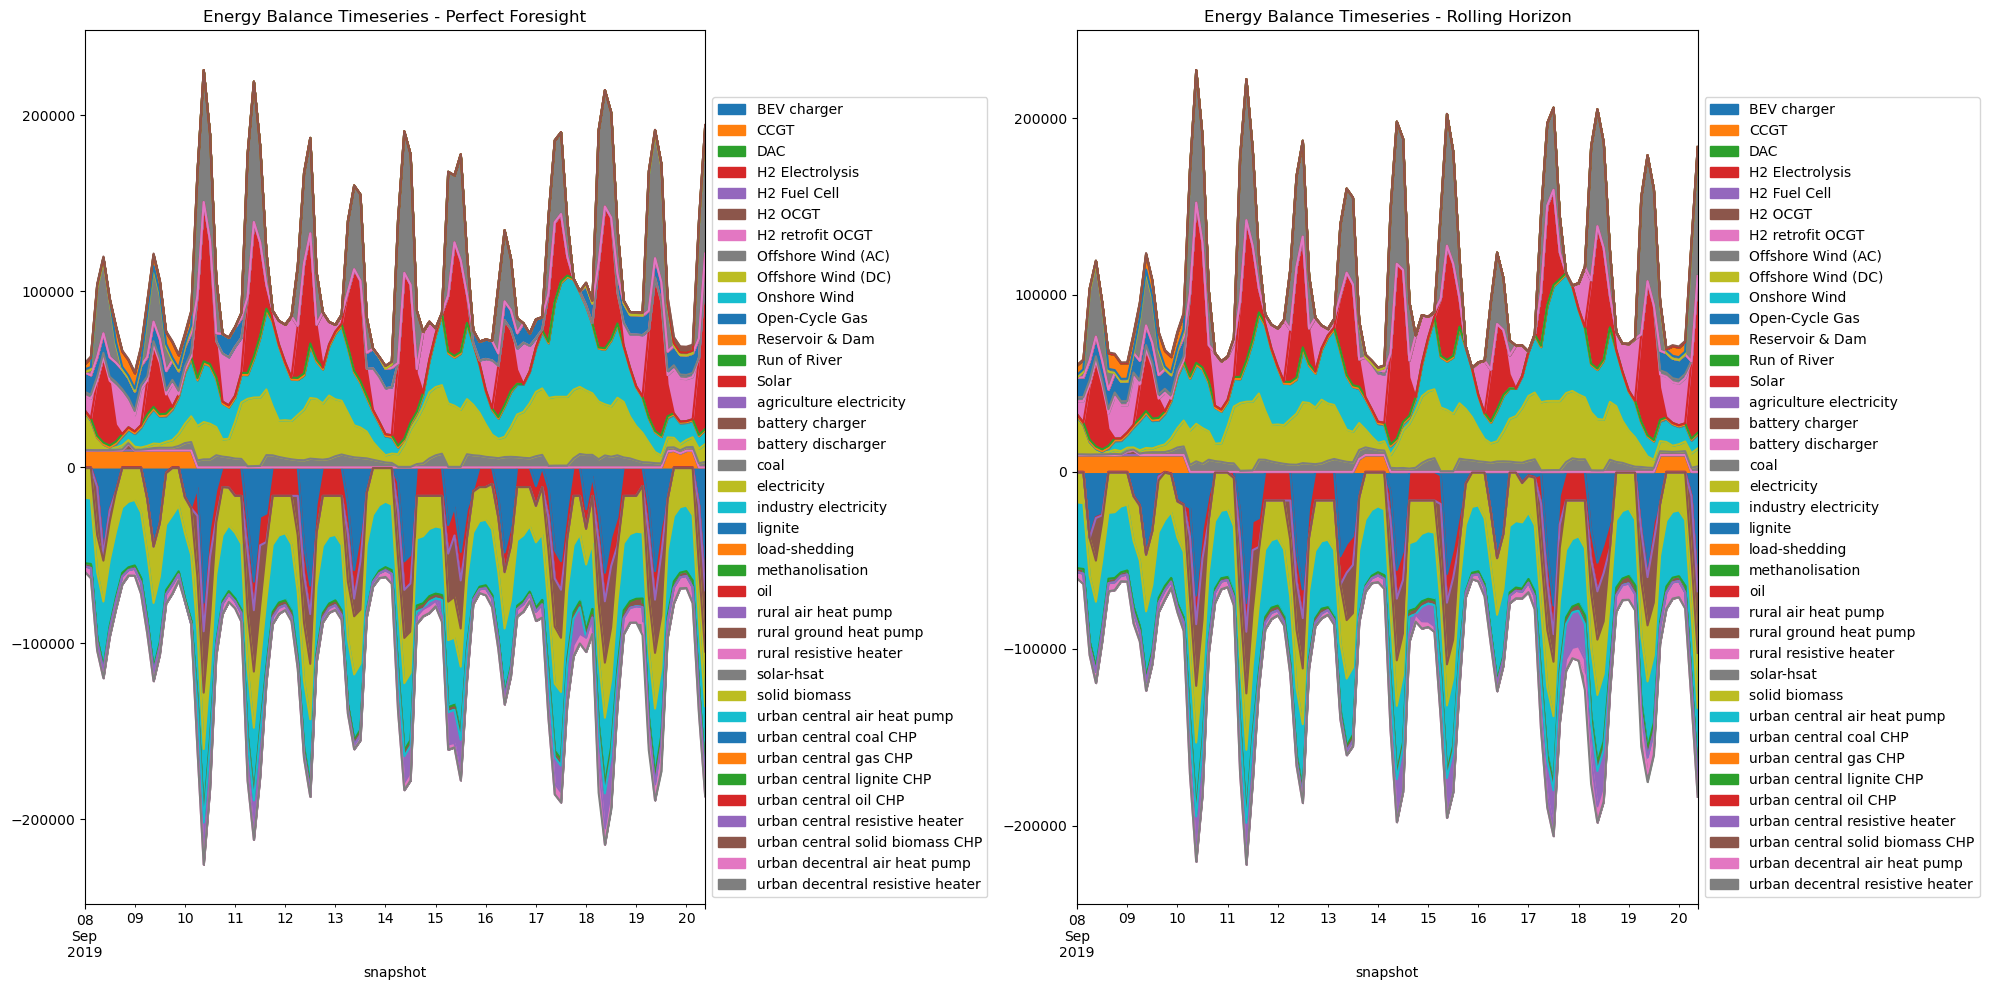

In [16]:
fig, ax = plt.subplots(1,2,figsize=(20,10))

n.statistics.energy_balance(aggregate_time=False).loc[:, :, "AC"].droplevel(0).iloc[
    :, 2000:2100
].groupby("carrier").sum().where(lambda x: np.abs(x) > 1).fillna(0).drop("Pumped Hydro Storage", axis=0, errors="ignore").T.plot.area(
    ax = ax[0],
    title="Energy Balance Timeseries - Perfect Foresight"
)
ax[0].legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
plt.tight_layout()

n_perfect_foresight.statistics.energy_balance(aggregate_time=False).loc[:, :, "AC"].droplevel(0).iloc[
    :, 2000:2100
].groupby("carrier").sum().where(lambda x: np.abs(x) > 1).fillna(0).drop("Pumped Hydro Storage", axis=0, errors="ignore").T.plot.area(
    ax = ax[1],
    title="Energy Balance Timeseries - Rolling Horizon"
)
ax[1].legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
plt.tight_layout()

In [17]:
# Wrapper Funktion um cf übergeben zu können
def change_wind_noise():
    # eigentliche funktion zum ändern der Constraints
    def change_wind(n, sns):
        rhs = n.model.constraints["Generator-fix-p-upper"].rhs
        years = [2035, 2030, 2025, 2020]

        for year in years:
            selector = {"Generator-fix": f"DE0 0 onwind-{year}"}
            scaling_factor = np.std(rhs.sel(selector).data)
            p_nom = n.generators.p_nom[f"DE0 0 onwind-{year}"]
            wind_power = rhs.sel(selector) + wind_noise(len(sns), scaling_factor)
            wind_power = wind_power.where(wind_power >= 0, 0)
            wind_power = wind_power.where(wind_power <= p_nom, p_nom)
            rhs.loc[selector] = wind_power

    return change_wind

def wind_noise(hours, scaling_factor):

    # 2. MSE-Werte für LSTM-Modell aus Tabelle bis 168h --> aus der Tabelle des Papers (0 von mir)
    horizons = np.array([0, 24, 48, 72, 96, 168, 336])
    mse_values = np.array([0, 0.499, 0.794, 0.899, 0.943, 1.011, 1.064])
    rmse_std = np.sqrt(mse_values)  # RMSE in Standardform

    # 3. Skaliere RMSE auf echte MW-Einheit
    rmse_MW = rmse_std * scaling_factor

    # 4. Interpolation der RMSE auf 144h
    interp_rmse = interp1d(horizons, rmse_MW, kind='linear', fill_value='extrapolate')
    rmse_per_hour = interp_rmse(np.arange(0, hours*3, 3))  # Stunden 1–144


    # 5. Rauschen generieren und synthetische Prognose erzeugen
    noise = np.random.normal(loc=0, scale=1.2*rmse_per_hour)
    #noise = np.clip(noise, 0, None)  # alles < 0 → 0, Rest bleibt
    return noise


In [18]:
n_wind_noise = pypsa.Network('base_s_1__none_2035_lt.nc')

# alle hydrogen related stores
stores = n_wind_noise.stores[n_wind_noise.stores.carrier.str.contains("H2", case=False, na=False)].index

# marginal price für alle der mean
for i in stores:
    n_wind_noise.stores.loc[i, 'marginal_cost'] = n_perfect_foresight.buses_t.marginal_price['DE0 0 H2'].mean()


n_wind_noise.stores.loc['DE0 0 H2 Store-2035', 'e_initial'] = 7177471
n_wind_noise.stores.loc['DE0 0 H2 Store-2035', 'e_cyclic'] = False

n_wind_noise.optimize.fix_optimal_capacities()
n_wind_noise.optimize.create_model()

n_wind_noise.optimize.optimize_with_rolling_horizon(
    horizon = 48,
    overlap = 8,
    solver_name = 'gurobi',
    extra_functionality = change_wind_noise()
)

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2000', 'DE0 0 urban central oil CHP-2000',
       'DE0 0 urban central gas CHP-2005', 'DE0 0 urban central oil CHP-2005',
       'DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central coal CHP-2015', 'DE0 0 urban central gas CHP-2015',
       'DE0 0 urban central lignite CHP-2015',
       'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central solid biomass CHP-2015',
       'DE0 0 urban central coal CHP-2020', 'DE0 0 urban central gas CHP-2020',
       'DE0 0 urban central lignite CHP-2020',
       'DE0 0 urban central oil CHP-2020',
       'DE0 0 urban central solid biomass CHP-2020', 'DE0 0 CCGT-1965',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-1995', 'DE0 0 CCGT-2000',
       'DE0 0 CCGT-2005', 'DE

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 1620 iterations and 0.04 seconds (0.05 work units)


INFO:gurobipy:Solved in 1620 iterations and 0.04 seconds (0.05 work units)


Optimal objective  8.958849999e+08


INFO:gurobipy:Optimal objective  8.958849999e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12048 primals, 24823 duals
Objective: 8.96e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-31 00:00:00:2019-02-05 21:00:00] (7/73).
Index(['load-shedding'], dtype='object', name='Generator')


KeyboardInterrupt: 

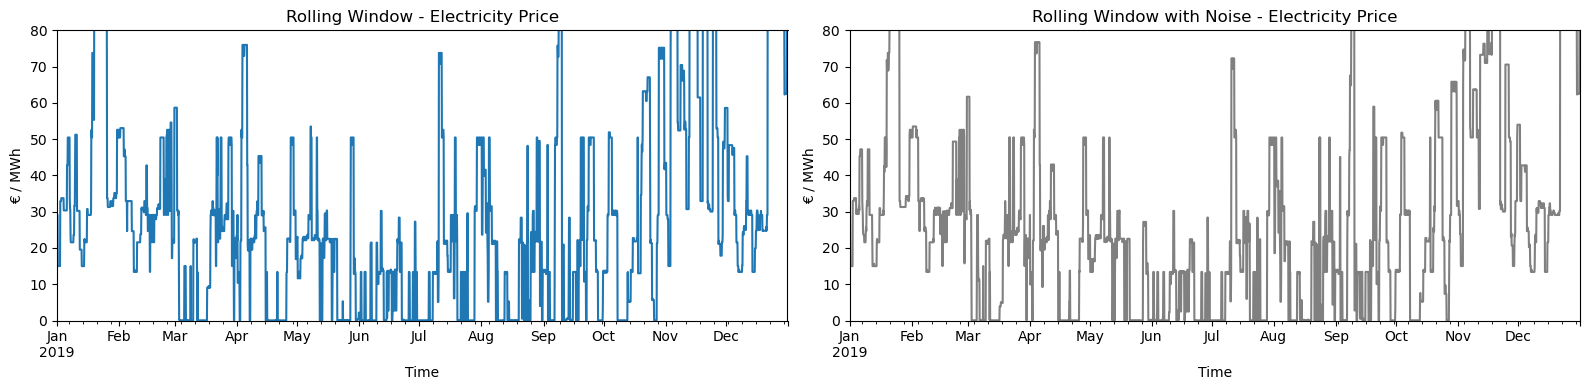

29.687082199913778
29.630199401515252


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(16,4))

n.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0],
    ylim=(0, 80),
    title = 'Rolling Window - Electricity Price'
)

n_wind_noise.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[1],
    ylim = (0, 80),
    title = 'Rolling Window with Noise - Electricity Price',
    color = 'grey'
)

ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[0].set_ylabel('€ / MWh')
ax[1].set_ylabel('€ / MWh')

plt.tight_layout()
plt.show()

print(n.buses_t.marginal_price['DE0 0'].mean())
print(n_wind_noise.buses_t.marginal_price['DE0 0'].mean())

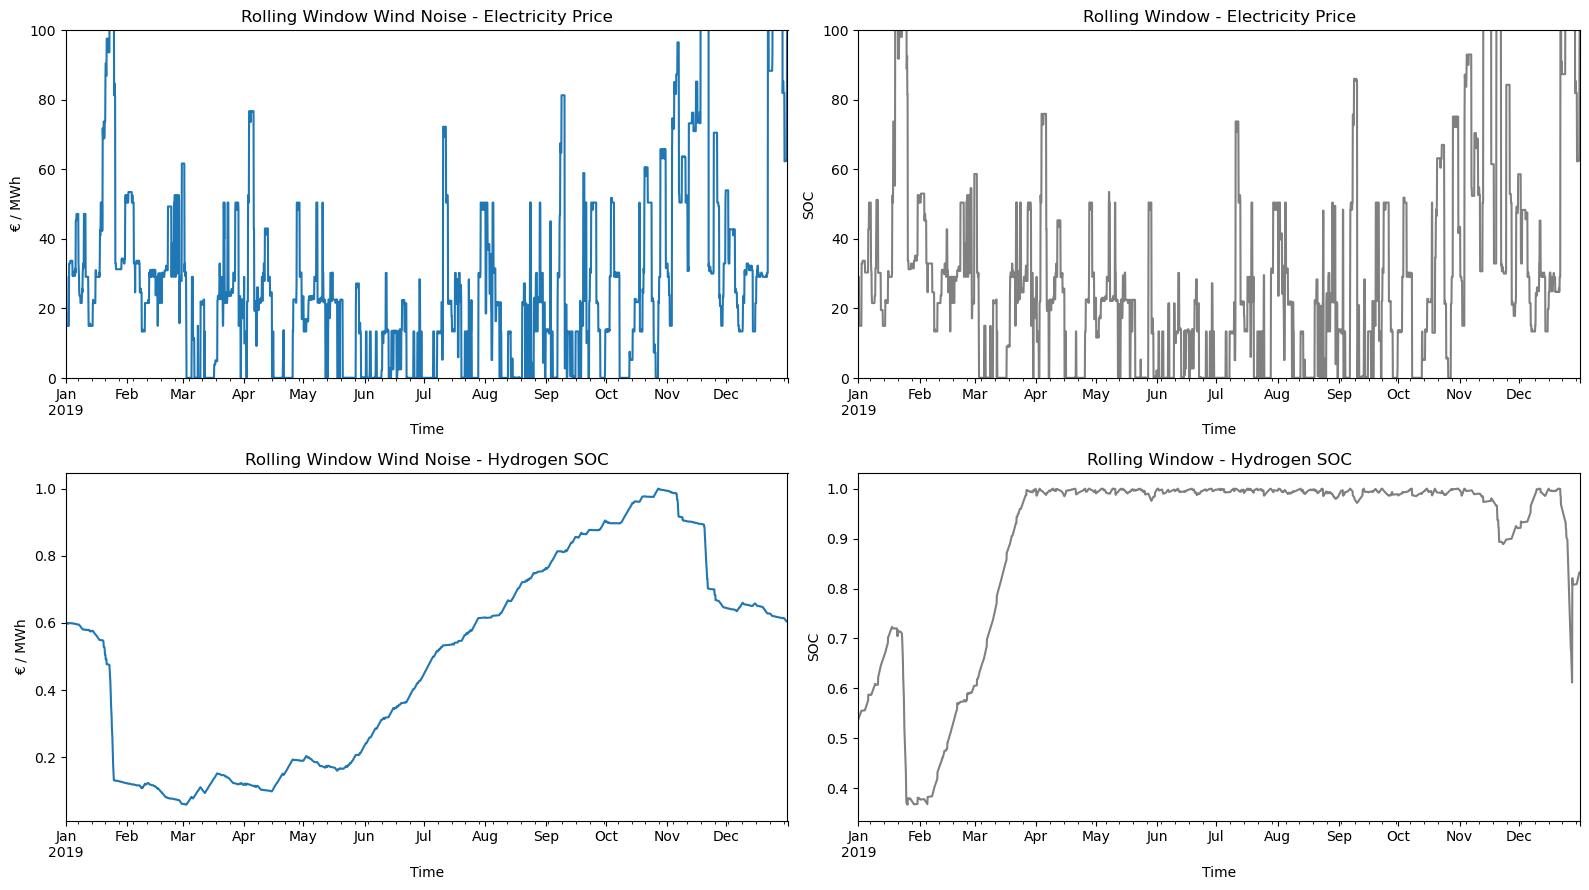

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(16,9))

n_wind_noise.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][0],
    ylim=(0, 100),
    title = 'Rolling Window Wind Noise - Electricity Price'
)

n.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][1],
    ylim = (0, 100),
    title = 'Rolling Window - Electricity Price',
    color = 'grey'
)

get_hydrogen_soc(n_perfect_foresight).plot(
    ax = ax[1][0],
    title = 'Rolling Window Wind Noise - Hydrogen SOC'
)
get_hydrogen_soc(n).plot(
    ax = ax[1][1],
    title = 'Rolling Window - Hydrogen SOC',
    color = 'grey'

)

ax[0][0].set_xlabel("Time")
ax[1][0].set_xlabel("Time")
ax[0][1].set_xlabel("Time")
ax[1][1].set_xlabel("Time")

ax[0][0].set_ylabel("€ / MWh")
ax[1][0].set_ylabel("€ / MWh")
ax[0][1].set_ylabel("SOC")
ax[1][1].set_ylabel("SOC")

plt.tight_layout()

In [ ]:
print(n.statistics.dispatch().loc["Generator", 'Onshore Wind'])
print(n_wind_noise.statistics.dispatch().loc["Generator", 'Onshore Wind'])

AttributeError: 'StatisticsAccessor' object has no attribute 'dispatch'

- genau das gleiche wie bei 45 auch, also liegt es vermutlich nicht nur an der erhöhten flexibilität

Nächste Schritte:
- liegt es vielleicht nicht nur an der flexibilität sondern noch an was anderem?
- die Co2 Constraints brauch man glaube ich, sonst ist das Preisniveau so niedrig, das könnte noch weitere Einflüsse haben
- ich wollte morgen mal ein paar paper von nicole ludwig lesen und ihr eine Mail schicken, vielleicht müssen wir uns aber noch weitere Sachen überlegen, sodass die Preise sich stärker verändern.